# GC content: Phenotype Prediction, Feature Selection, and Exploration of Phenotypic Signal Distribution

This notebook provides a pipeline for predicting microbial oxygen-use phenotypes from genomic data and identifying the genomic features associated with these phenotypes.

We train and evaluate an XGBoost classifier using COG count tables. Genomes are split into training and test sets at a specified taxonomic level, such that all genomes belonging to a given taxonomic group are assigned exclusively to either the training or the test set. The notebook is designed to be run for a single taxonomic-level split at a time.

To identify genomic footprints and the most informative COGs contributing to phenotype prediction, we employ two complementary feature-selection approaches:

- SHAP values, computed from the trained XGBoost model (model-dependent feature importance);
- Markov blanket discovery, a model-agnostic method for identifying features that contain information about the phenotype.

To investigate how phenotypic information is distributed across the genome, we retrain and evaluate models on progressively larger and smaller feature subsets ranked by SHAP importance. This analysis reveals whether predictive signal is concentrated in a small number of features or distributed across many genomic traits. 

### 1. Read train/test datasets

First, we read the input files generated by *taxa_level_split.py*. The script generates 6 output files for the chosen [tax_level] of the train/test split, that are used as main inputs in this notebook. The files are the following:

- train_data_[tax_level]_tax_level : training count table,
- train_annot_[tax_level]_tax_level : training annotations,
- train_taxa_names_[tax_level]_tax_level : [tax_level] name of each training sample,

\+ 3 similar test tables. Those files should be stored in the corresponding directory for the phenotype.

In order to run the phenotype prediction pipeline in this notebook, the data directory with the input files, and [tax_level] of the train/test split should be specified below.

## Read the input data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

from utils.utils import read_ogt_data

# SPECIFY THE DESIRED TAXONOMY SPLIT LEVEL HERE!
TAX_LEVEL = "phylum" # <--------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_gc" # <--------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <----------- number of splits to read and process is here!!

GC_BOUNDARY = 50   # <----------------- the boundary between two binary classes

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"

In [2]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_train, y_train, X_column_names, taxa_group_names_train, genome_accesion_train = read_ogt_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE, return_genome_accession = True)
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_test, y_test, X_column_names, taxa_group_names_test, genome_accesion_test = read_ogt_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE, return_genome_accession = True)

    X_test = (X_test > 0).int()
    X_train = (X_train > 0).int()

    if sum(y_train)/len(y_train) < 0.01 or  sum(y_test)/len(y_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue
    if TAX_LEVEL == "random" or TAX_LEVEL == "domain":
        taxa_group_names_train = None
        taxa_group_names_test = None
    
    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_train
    curr_split_dict["y_train"] = y_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["genome_accesion_train"] = genome_accesion_train
    
    curr_split_dict["X_test"] = X_test
    curr_split_dict["y_test"] = y_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["genome_accesion_test"] = genome_accesion_test
    
    curr_split_dict["feature_names"] = X_column_names

    all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")  

Number of added splits = 30


In [3]:
mean_train = np.mean(y_train.cpu().squeeze().numpy())
mean_test = np.mean(y_test.cpu().squeeze().numpy())

print(f"Average GC of the train set = {mean_train}")
print(f"Average GC of the train set = {mean_test}")

Average GC of the train set = 52.082759857177734
Average GC of the train set = 52.45646667480469


In [4]:
# Concatenate train and test for the 2D visualization
y_label = torch.cat((y_train, y_test), dim=0)
X_val = torch.cat((X_train, X_test), dim=0)
if TAX_LEVEL != "random":
    taxa_group_names = taxa_group_names_train + taxa_group_names_test

In [5]:
# Create the output directory if it doesn't exist
if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

### 2. Data visualization

2568
1166
4789


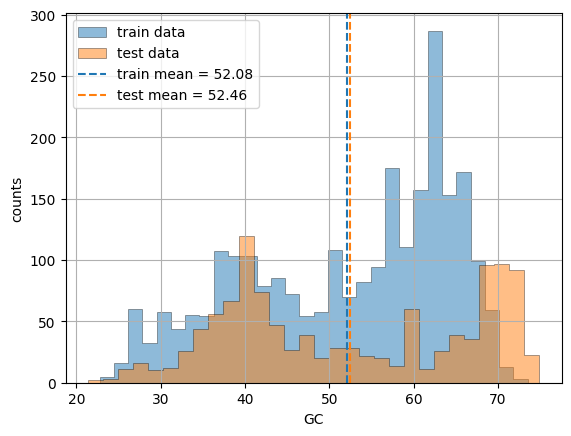

In [3]:
hist = plt.hist(y_train.cpu(), bins = 30, density = False, label = "train data", alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:blue')
hist = plt.hist(y_test.cpu(), bins = 30, density = False, label = "test data", alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:orange')
mean_value = y_train.cpu().mean().item()
plt.axvline(mean_value, color='tab:blue', linestyle='--', linewidth=1.5, label=f'train mean = {mean_value:.2f}')
mean_value = y_test.cpu().mean().item()
plt.axvline(mean_value, color='tab:orange', linestyle='--', linewidth=1.5, label=f'test mean = {mean_value:.2f}')

plt.xlabel("GC")
plt.ylabel("counts")
plt.grid(True)
plt.legend();
print(len(y_train.cpu()))
print(len(y_test.cpu()))
print(len(X_column_names))

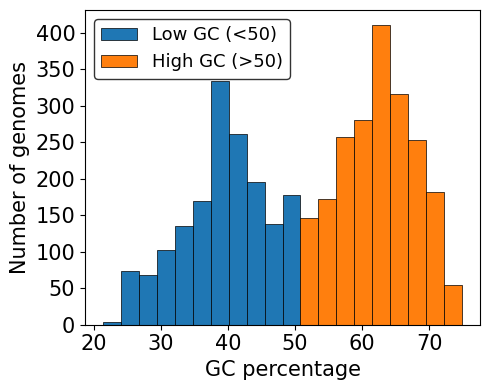

In [7]:
import matplotlib.patches as mpatches

FONTSIZE = 15

data = y_label.cpu().numpy()
threshold = GC_BOUNDARY

counts, bins = np.histogram(data, bins=20)

plt.figure(figsize=(5,4))

left_max_y = 0
right_max_y = 0

# Plot each bin individually
for i in range(len(bins) - 1):
    bin_center = (bins[i] + bins[i + 1]) / 2
    color = 'tab:blue' if bin_center < threshold else 'tab:orange'
    bar = plt.bar(bins[i], counts[i], width=bins[i + 1] - bins[i],
                  align='edge', color=color, edgecolor='black', linewidth=0.5)
    
    # Track max heights for annotation placement
    if bin_center < threshold:
        left_max_y = max(left_max_y, counts[i])
    else:
        right_max_y = max(right_max_y, counts[i])

# Add custom legend entries
meso_patch = mpatches.Patch(facecolor='tab:blue', label='Low GC (<50)', edgecolor='black', linewidth=0.5)
thermo_patch = mpatches.Patch(facecolor='tab:orange', label='High GC (>50)', edgecolor='black', linewidth=0.5)

# Add to legend
plt.legend(handles=[meso_patch, thermo_patch], fontsize=FONTSIZE - 2, edgecolor='black')

# Final formatting
plt.xlabel("GC percentage", fontsize=FONTSIZE)
plt.ylabel("Number of genomes", fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
plt.yticks(fontsize=FONTSIZE)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/data_distrib.svg", format="svg")

Shape of the projected data = (3734, 2)


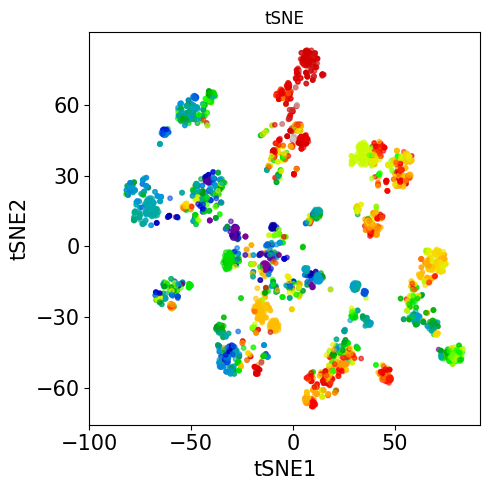

In [8]:
from utils.utils import pca_run_and_plot, tsne_plot

plt.figure(figsize=(5,5))

X_train, y_train, X_test, y_test = X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu()
colorbar = False

#t-SNE space
tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, y_label.cpu(), None, colorbar);
plt.xlabel("tSNE1", fontsize = FONTSIZE)
plt.ylabel("tSNE2", fontsize = FONTSIZE)
plt.xticks([-100, -50, 0, 50], fontsize = FONTSIZE)
plt.yticks([-60, -30, 0, 30, 60], fontsize = FONTSIZE)

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_orig_phenot.svg", format="svg")
plt.show()

### 3. XGBoost training and testing

In this section we train XGBoost classifier for the phenotype prediction, and perform the feature selection analysisc based on three different methods.

First, we find the baseline (for all GOGs) test and cross-validation accuracy measures. As the accuracy measures, we use the following:

- accuracy = $\frac{TP+TN}{TP+TN+FP+FN}$,
- precision = $\frac{TP}{TP+FP}$,
- recall = $\frac{TP}{TP+FN}$,
- F1 = $2 \frac{precision \times recall}{precision + recall}$.

In [6]:
import warnings

from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

from sklearn.metrics import mean_squared_error,r2_score

In [7]:
def label_ogt_range(y,high_thresh=GC_BOUNDARY):
    labels = []
    for val in y:
        if val < high_thresh:
            labels.append('low')
        else:
            labels.append('high')
    return np.array(labels)

In [8]:
from feature_selection.feature_selection_utils import xgboost_mixture_of_experts_2_class_cv_full

cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)

test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]

    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train, y_label_train, range_ids, sample_weights, X_val_test, y_label_test, taxonomy_labels=taxa_group_names_train, cv_flag=True)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = GC_BOUNDARY
    y_label_test_bin  = (y_label_test.squeeze() > temp_bound).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
        mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["balanced_accuracy"].append(0.5)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["mcc"].append(mcc)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > temp_bound).squeeze()
    mask_low = (y_true < temp_bound).squeeze()
    
    # Compute metrics for y_true > temp_bound
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < temp_bound
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)

    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > temp_bound).squeeze()
    mask_low = (y_true < temp_bound).squeeze()
    
    # Compute metrics for y_true > temp_bound
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < temp_bound
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing 0 split...
Processing 1 split...
Processing 2 split...
Processing 3 split...
Processing 4 split...
Processing 5 split...
Processing 6 split...
Processing 7 split...
Processing 8 split...
Processing 9 split...
Processing 10 split...
Processing 11 split...
Processing 12 split...
Processing 13 split...
Processing 14 split...
Processing 15 split...
Processing 16 split...
Processing 17 split...
Processing 18 split...
Processing 19 split...
Processing 20 split...
Processing 21 split...
Processing 22 split...
Processing 23 split...
Processing 24 split...
Processing 25 split...
Processing 26 split...
Processing 27 split...
Processing 28 split...
Processing 29 split...


/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy

In [9]:
cv_accur_dict_mean.keys()

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'ece', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high', 'rmse', 'r2'])

df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics.csv")

print(df)

                     cv mean    cv std  test mean  test std  \
balanced_accuracy   0.675024  0.062462   0.695522  0.062517   
accuracy            0.691387  0.066319   0.760631  0.070442   
precision           0.780179  0.091715   0.814474  0.157545   
recall              0.669722  0.137406   0.708525  0.212980   
f1                  0.715947  0.111903   0.739133  0.178021   
mcc                 0.345523  0.122012   0.401764  0.101678   
ece                 0.185375  0.054978   0.154629  0.067320   
rmse_low            9.999567  1.401898   9.288035  1.775498   
r2_low             -1.698518  0.738921  -1.372411  0.795387   
rmse_high          13.043638  3.033910  10.924066  3.363504   
r2_high            -3.722520  1.573447  -2.812746  2.001217   
rmse               11.638023  1.615896  10.005195  1.748524   
r2                  0.161632  0.176827   0.221132  0.214548   

                   test baseline mean  test baseline std  
balanced_accuracy            0.500000           0.000000  

### 4. Phylogeny based predictions

#### 4.1. Phylogeny agreement

In this section we find the phenotype agreement across taxonomy groups for each taxonomy level.

In [6]:
# Read a phenotype annotation file
all_gene_annot = "../data_gc/gc_annot.csv"

df_annot = pd.read_csv(all_gene_annot, sep=",")
all_gen_access = df_annot["accession"]
df_annot

,accession,gc_content
0,GB_GCA_000023725.1,42.70
1,GB_GCA_000026125.1,54.30
2,GB_GCA_000043285.1,27.40
3,GB_GCA_000063505.1,60.20
4,GB_GCA_000063525.1,60.80
...,...,...
6582,RS_GCF_946478525.1,42.30
6583,RS_GCF_949281285.1,61.31
6584,RS_GCF_951793255.1,63.65
6585,RS_GCF_958453765.1,47.64


In [7]:
# Read the gtdb metadata and merge them with the phenotype annotation file
gtdb_arc_name = "../data_preparation/gtdb_files/ar122_metadata_r202.tsv"
gtdb_arc = pd.read_csv(gtdb_arc_name, sep="\t")
gtdb_arc = gtdb_arc[["accession", "gtdb_taxonomy"]]

gtdb_bac_name = "../data_preparation/gtdb_files/bac120_metadata_r202.tsv"
gtdb_bac = pd.read_csv(gtdb_bac_name, sep="\t")
gtdb_bac = gtdb_bac[["accession", "gtdb_taxonomy"]]

df_combined = pd.concat([gtdb_arc, gtdb_bac])

df_annot_wuth_taxa = pd.merge(df_annot, df_combined, on="accession", how="inner")

# The taxonomy levels for which the phenotype agreement index is calculated
levels = ["domain","phylum","class","order","family","genus","species"]

df_annot_wuth_taxa[levels] = (
    df_annot_wuth_taxa["gtdb_taxonomy"]
    .str.split(";", expand=True)
    .reindex(columns=range(7))  # ensures 7 columns even if missing
)

# remove prefixes like d__, p__, etc.
for col in levels:
    df_annot_wuth_taxa[col] = df_annot_wuth_taxa[col].str.replace(r"^[a-z]__", "", regex=True)

# drop original column
df_annot_wuth_taxa = df_annot_wuth_taxa.drop(columns=["gtdb_taxonomy"])
df_annot_wuth_taxa["gc_content_binary"] = (df_annot_wuth_taxa["gc_content"] > GC_BOUNDARY).astype(int)
df_annot_wuth_taxa

/scratch/ipykernel_547370/1034978119.py:7: DtypeWarning: Columns (61,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_bac = pd.read_csv(gtdb_bac_name, sep="\t")


,accession,gc_content,domain,phylum,class,order,family,genus,species,gc_content_binary
0,GB_GCA_000091165.1,58.600000,Bacteria,Methylomirabilota,Methylomirabilia,Methylomirabilales,Methylomirabilaceae,Methylomirabilis,Methylomirabilis oxyfera,1
1,GB_GCA_000173575.1,62.900000,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Paraburkholderia,Paraburkholderia sp000173575,1
2,GB_GCA_000246735.1,51.558983,Archaea,Thermoplasmatota,Poseidoniia_A,Poseidoniales,Poseidoniaceae,MGIIa-L1,MGIIa-L1 sp000246735,1
3,GB_GCA_000270325.1,51.600000,Archaea,Thermoproteota,Nitrososphaeria,Caldarchaeales,Caldarchaeaceae,Caldarchaeum,Caldarchaeum subterraneum_A,1
4,GB_GCA_000387965.1,24.300000,Archaea,Nanoarchaeota,Nanoarchaeia,Nanoarchaeales,Nanopusillaceae,Nanopusillus,Nanopusillus stetteri,0
...,...,...,...,...,...,...,...,...,...,...
3729,RS_GCF_902832845.1,67.124000,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Burkholderia,Burkholderia metallica,1
3730,RS_GCF_902833085.1,67.168000,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Burkholderia,Burkholderia ubonensis,1
3731,RS_GCF_902833645.1,61.785000,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Paraburkholderia,Paraburkholderia fungorum,1
3732,RS_GCF_902859825.1,62.529000,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Paraburkholderia,Paraburkholderia phenoliruptrix,1


In [8]:
def mean_pairwise_agreement_binary(values):
    """
    Calculates the percentage of similar pairs of elements of the phenotype vector
    """
    values = np.array(values)

    if len(values) < 2:
        return np.nan

    y = np.array([{0: 0, 1: 1}[v] for v in values])

    n = len(y)
    n1 = y.sum()
    n0 = n - n1

    total_pairs = n * (n - 1) / 2
    same_pairs = n1 * (n1 - 1) / 2 + n0 * (n0 - 1) / 2

    return same_pairs / total_pairs

def compute_binary_stats(df, level):
    """
    Calculates mean and std scores of the phenotype agreement index across taxonomy groups at the specified taxonomy level 
    """
    p = np.mean(np.array([{0: 0, 1: 1}[v] for v in df["gc_content_binary"]]))
    baseline = p**2 + (1 - p)**2

    def group_score(x):
        A = mean_pairwise_agreement_binary(x)
        if np.isnan(A) or baseline == 1:
            return np.nan
        return (A - baseline) / (1 - baseline)

    group_vals = (
        df.groupby(level)["gc_content_binary"]
          .apply(group_score)
          .dropna()
    )
    
    return {
        "mean": group_vals.mean(),
        "std": group_vals.std()
    }    

In [9]:
# Calculate the phenotype similarity scores across different taxonomy levels
levels = ["genus", "family", "order", "class", "phylum", "domain"]

results = {}

for level in levels:
    results[level] = compute_binary_stats(df_annot_wuth_taxa, level)

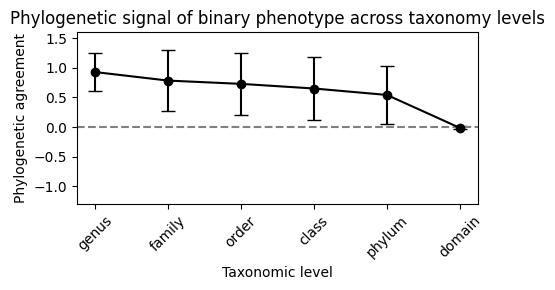

In [10]:
# Visualize the results

import matplotlib.pyplot as plt
import numpy as np



means = [results[l]["mean"] for l in levels]
stds  = [results[l]["std"] for l in levels]

x = np.arange(len(levels))

plt.figure(figsize=(5,3))

plt.errorbar(
    x, means,
    yerr=stds,
    marker='o',
    capsize=5,
    linestyle='-',
    c = "black"
)

plt.axhline(0, linestyle='--', c = "grey")

plt.xticks(x, levels, rotation=45)
plt.xlabel("Taxonomic level")
plt.ylabel("Phylogenetic agreement")
plt.title("Phylogenetic signal of binary phenotype across taxonomy levels")

plt.ylim(-1.3, 1.6)  # important for probabilities

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/phylogen_agreement_decay.svg", format="svg", bbox_inches='tight') #<-------save as pdf

plt.show()

In [11]:
# Same but for continuous phenotype values
import numpy as np

def mean_pairwise_abs_diff(values):
    values = np.array(values, dtype=float)
    n = len(values)
    
    if n < 10:
        return np.nan  # avoid noisy small groups
    
    diffs = np.abs(values[:, None] - values[None, :])
    i, j = np.triu_indices(n, k=1)
    
    return diffs[i, j].mean()

def compute_continuous_stats(df, level, col="gc_content"):
    
    group_vals = (
        df.groupby(level)[col]
          .apply(mean_pairwise_abs_diff)
          .dropna()
    )
    
    return {
        "mean": group_vals.mean(),
        "std": group_vals.std()
    }

def random_pairwise_abs_diff_fast(values, n_pairs=10000, seed=42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)

    i = rng.integers(0, n, size=n_pairs)
    j = rng.integers(0, n, size=n_pairs)

    mask = i != j
    diffs = np.abs(values[i[mask]] - values[j[mask]])

    return diffs.mean(), diffs.std()

In [12]:
levels = ["genus", "family", "order", "class", "phylum", "domain"]

results = {}

for level in levels:
    results[level] = compute_continuous_stats(df_annot_wuth_taxa, level, col="gc_content")

baseline_mean, baseline_std = random_pairwise_abs_diff_fast(df_annot_wuth_taxa["gc_content"].values)
baseline_mean

np.float64(14.580507154161666)

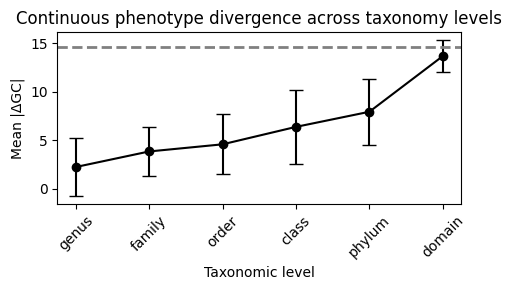

In [13]:
import matplotlib.pyplot as plt
import numpy as np

means = [results[l]["mean"] for l in levels]
stds  = [results[l]["std"] for l in levels]

x = np.arange(len(levels))

plt.figure(figsize=(5,3))

plt.errorbar(
    x, means,
    yerr=stds,
    marker='o',
    capsize=5,
    linestyle='-',
    c = "black"
)

plt.axhline(
    y=baseline_mean,
    linestyle='--',
    color='grey',
    linewidth=2,
    label="Random baseline"
)

plt.xticks(x, levels, rotation=45)
plt.xlabel("Taxonomic level")
plt.ylabel("Mean |ΔGC|")
plt.title("Continuous phenotype divergence across taxonomy levels")
plt.savefig(f"{OUTPUT_DIRECTORY}/phylogen_agreement_decay_contin.svg", format="svg", bbox_inches='tight')

plt.tight_layout()
plt.show()

#### 4.2. Predicting phenotypes based on the closes taxonomy group

In [14]:
from ete3 import Tree

# Load GTDB trees
tree_path_bact = "../phylo_trees/bac120_r220.tree"  #bac120_r220.tree   /bac120_r95.tree
tree_bact = Tree(tree_path_bact, format=1, quoted_node_names=True)
nodes_bact = {leaf.name: leaf for leaf in tree_bact.iter_leaves()}

leaf_names_bact = set(tree_bact.get_leaf_names())

tree_path_arch = "../phylo_trees/ar53_r220.tree" # ar53_r220.tree" #ar122_r95.tree"
tree_arch = Tree(tree_path_arch, format=1, quoted_node_names=True)
nodes_arch = {leaf.name: leaf for leaf in tree_arch.iter_leaves()}

leaf_names_arch = set(tree_arch.get_leaf_names())

#  Find the percentage of the annotated genomes that are not present in the tree genomes
count_not_present = 0

for genome in all_gen_access:
    if genome not in leaf_names_bact and genome not in leaf_names_arch:
        count_not_present += 1
count_not_present/len(set(all_gen_access))  

0.0

In [15]:
# Make phylogenetic prediction

from tqdm import tqdm
from utils.utils import one_split_phylogeny_prediction_contin, evaluate_metrics_contin_and_bin

metrics_all_splits = defaultdict(int)
for split_id in tqdm(all_splits_dict.keys(), desc="Processing splits..."):

    genome_accesion_train = all_splits_dict[split_id]["genome_accesion_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    genome_accesion_test = all_splits_dict[split_id]["genome_accesion_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]
    
    train_labels_dict = defaultdict(str)
    for idx, accesion in enumerate(genome_accesion_train):
        train_labels_dict[accesion] = y_label_train[idx].item()
    genome_accesion_train = set(genome_accesion_train)    

    test_labels_dict = defaultdict(str)
    for idx, accesion in enumerate(genome_accesion_test):
        test_labels_dict[accesion] = y_label_test[idx].item()
    
    if TAX_LEVEL not in {"random", "domain"}:    
        true_test_labels, predict_test_labels_contin, predict_test_labels_binary = one_split_phylogeny_prediction_contin(genome_accesion_train, genome_accesion_test, train_labels_dict, test_labels_dict, nodes_bact, nodes_arch)
        
        metrics = evaluate_metrics_contin_and_bin(true_test_labels, predict_test_labels_contin, predict_test_labels_binary, GC_BOUNDARY)
        metrics_all_splits[split_id] = metrics

    elif TAX_LEVEL == "random":   
        true_test_labels = []
        predict_test_labels_contin = []
        predict_test_labels_binary = []
        for genome_test_ind, genome_test_name in enumerate(genome_accesion_test):
            dist_min = float("inf")
            dist_label = None
            
            # Bacteria
            if genome_test_name in nodes_bact:
                for j, genome_train_name in enumerate(genome_accesion_train):
                    if genome_train_name in nodes_bact:
                        curr_dist = nodes_bact[genome_test_name].get_distance(nodes_bact[genome_train_name])
                        if curr_dist < dist_min:
                            dist_min = curr_dist
                            dist_label = train_labels_dict[genome_train_name]
                true_test_labels.append(test_labels_dict[genome_test_name])
                predict_test_labels_contin.append(dist_label)
                predict_test_labels_binary.append(int(dist_label>GC_BOUNDARY))

            # Archaea
            if genome_test_name in nodes_arch:
                for j, genome_train_name in enumerate(genome_accesion_train):
                    if genome_train_name in nodes_arch:
                        curr_dist = nodes_arch[genome_test_name].get_distance(nodes_arch[genome_train_name])
                        if curr_dist < dist_min:
                            dist_min = curr_dist
                            dist_label = train_labels_dict[genome_train_name]
                true_test_labels.append(test_labels_dict[genome_test_name])
                predict_test_labels_contin.append(dist_label)  
                predict_test_labels_binary.append(int(dist_label>GC_BOUNDARY))
        
        metrics = evaluate_metrics_contin_and_bin(true_test_labels, predict_test_labels_contin, predict_test_labels_binary)
        metrics_all_splits[split_id] = metrics

    elif TAX_LEVEL == "domain":   
        predict_test_labels_contin = [round(y_label_train.mean().item())]*len(y_label_test)

        y_label_train_bin = [int(yi.item()>GC_BOUNDARY) for yi in y_label_train]
        predict_test_labels_binary =  [round(np.mean(y_label_train_bin))]*len(y_label_test)
        
        metrics = evaluate_metrics_contin_and_bin(y_label_test, predict_test_labels_contin, predict_test_labels_binary)
        metrics_all_splits[split_id] = metrics

Processing splits...: 100%|█████████████████████████████████████████████████████████| 30/30 [3:15:58<00:00, 391.96s/it]


In [16]:
phylogen_accur_metrics = defaultdict(list)

for split_id in metrics_all_splits.keys():
    for metric in metrics_all_splits[split_id].keys():
        phylogen_accur_metrics[metric].append(metrics_all_splits[split_id][metric])

phylog_metrics_mean = defaultdict(str)
phylog_metrics_std = defaultdict(str)

for metric in phylogen_accur_metrics.keys():
    phylog_metrics_mean[metric] = np.mean(phylogen_accur_metrics[metric])
    phylog_metrics_std[metric] = np.std(phylogen_accur_metrics[metric])

In [17]:
metrics = {"phylog mean" : phylog_metrics_mean, "phylog std": phylog_metrics_std} 
df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy', 'precision', 'recall', 'f1', 'mcc', 'rmse', 'r2'])
df.to_csv(f"{OUTPUT_DIRECTORY}/phologeny_predict_metrics.csv")    
df    

,phylog mean,phylog std
balanced_accuracy,0.468222,0.168954
precision,0.509433,0.198621
recall,0.468222,0.168954
f1,0.429357,0.181215
mcc,-0.040165,0.346665
rmse,13.972092,4.924322
r2,-0.496755,0.770957


## 5. Feature Selection

### 5.1 Markov Blankets

In [83]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from feature_selection.feature_selection_utils import iamb
import warnings
from sklearn.preprocessing import KBinsDiscretizer
import json

filename = f"{OUTPUT_DIRECTORY}/markov_boundaries.json"
all_markov_bound_dict = defaultdict(int)

# Read the file with MBs if it already exists
if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_markov_bound_dict = json.load(f)
else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        # Get the train data
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
    
        X_np = X_val_train.cpu().numpy()  
        y_np = y_label_train.squeeze().cpu().numpy()  #y_label_train.cpu().numpy()  
    
        # Suppress only the specific warning from KBinsDiscretizer about small bin widths
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Feature .* is constant and will be replaced with 0.")
            warnings.filterwarnings("ignore", message="Your system has an old version of glibc.*")
            warnings.filterwarnings("ignore", message="Bins whose width are too small")

            X_np = (X_np > 0).astype(int)
            
            selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
            X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])
        
            disc = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
            y_disc = disc.fit_transform(y_np.reshape(-1, 1)).ravel()

            mutual_info = mutual_info_classif(X_np, y_disc, random_state=42)
            sorted_indices = np.argsort(mutual_info)[::-1] 
            N = 500
            top_N_indices = sorted_indices[:N]
           
            X_filtered = X_filtered.iloc[:, top_N_indices]
            print(X_filtered.shape)
            
            # Main MB algorithm    
            markov_boundary = iamb(X_filtered, y_disc, contin = False, alpha=0.01, verbose=False)
        print("Markov Boundary:", markov_boundary)
    
        all_markov_bound_dict[split_id] = markov_boundary

    # Save as json
    with open(filename, "w") as f:
        json.dump(dict(all_markov_bound_dict), f, indent=2)

Reading the existing file...


In [85]:
# Find the frequencies of all MB features across all data splits
num_splits = len(all_markov_bound_dict.keys())

all_cogs = sorted(set(cog for lst in all_markov_bound_dict.values() for cog in lst))
presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_markov_bound_dict])
for i, cogs in all_markov_bound_dict.items():
    presence_df.loc[cogs, f"Split_{i}"] = 1

# Add frequency column
presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# Sort by frequency
presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)

In [ ]:
# Find the average MB lengths across all data splits
mb_lengths = []
all_markov_bound_dict_with_res = {}

for split_id in all_markov_bound_dict.keys():
    mb_lengths.append(len(all_markov_bound_dict[split_id]))
    markov_bound = all_markov_bound_dict[split_id]
    indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]
    split_dict = defaultdict(str)
    split_dict["MB"] = markov_bound[:]
    all_markov_bound_dict_with_res[split_id] = split_dict.copy()

print(f"Average MB length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")   

In [87]:
dict_mb_stats["jaccard_aver"] = np.mean(jacc_idices)
dict_mb_stats["jaccard_std"] = np.std(jacc_idices)
print(f"Ave. Jaccard indec = {np.mean(jacc_idices)}; std = {np.std(jacc_idices)}")

Ave. Jaccard indec = 0.04122932944619838; std = 0.044303796543321255


In [89]:
# Save to CSV
dict_mb_stats = defaultdict(str)
dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
dict_mb_stats["mb_length_std"] = np.std(mb_lengths)
df = pd.DataFrame([dict_mb_stats])

# Save to CSV
df.to_csv(f"{OUTPUT_DIRECTORY}/mb_summary.csv", index=False)
df

,jaccard_aver,jaccard_std,mb_length_aver,mb_length_std
0,0.041229,0.044304,19.133333,2.539466


In [90]:
# Find the average MB across all data splits

import math

aver_mb_len = math.ceil(np.mean(mb_lengths))
aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

with open(f"{OUTPUT_DIRECTORY}/aver_mb.txt", "w") as f:
    f.write(f"{aver_m_names}\n")
        
aver_m_names

['COG1112',
 'COG1432',
 'COG1881',
 'COG3544',
 'COG3119',
 'COG2094',
 'COG1487',
 'COG5507',
 'COG1682',
 'COG2159',
 'COG1793',
 'COG1230',
 'COG2837',
 'COG3971',
 'COG1004',
 'COG1018',
 'COG0073',
 'COG2227',
 'COG1319',
 'COG1520']

### 5.2 Check model performance on the Markov Blanket

In [92]:
# Calculate the baseline accuracies based on the test annotation vectors

test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    temp_bound = GC_BOUNDARY
    y_label_test_bin  = (y_label_test.squeeze() > GC_BOUNDARY).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
        # Accuracy
        accuracy = (tp + tn) / N_tot
        
        # Matthews correlation coefficient
        numerator = (tp * tn) - (fp * fn)
        denominator = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
        mcc = numerator / denominator if denominator != 0 else 0
    
        # Append to dict
        test_accur_dict_splits_baseline["accuracy"].append(accuracy)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["roc_auc"].append(0)
        test_accur_dict_splits_baseline["mcc"].append(mcc)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in test_accur_dict_splits_baseline.keys():
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics_baseline = {"test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
metrics_baseline

{'test baseline mean': defaultdict(float,
             {'accuracy': np.float64(0.5),
              'precision': np.float64(0.6376130379696168),
              'recall': np.float64(0.5),
              'f1': np.float64(0.5405181224218542),
              'roc_auc': np.float64(0.0),
              'mcc': np.float64(0.0),
              'r2': np.float64(0.0),
              'rmse': np.float64(11.524237381813196)}),
 'test baseline std': defaultdict(float,
             {'accuracy': np.float64(0.0),
              'precision': np.float64(0.21711561994410872),
              'recall': np.float64(0.0),
              'f1': np.float64(0.10577529933504252),
              'roc_auc': np.float64(0.0),
              'mcc': np.float64(0.0),
              'r2': np.float64(0.0),
              'rmse': np.float64(1.896587760731316)})}

In [35]:
# # Explore the accuracies on different MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# def find_accuracies_on_restricted_feat_space(all_splits_dict, feature_condit):
#     cv_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits = defaultdict(list)
#     print(f"Processing splits...")
#     for split_id in all_markov_bound_dict_with_res.keys():
#         split_id = str(split_id)
        
#         X_val_train = all_splits_dict[int(split_id)]["X_train"]
#         y_label_train = all_splits_dict[int(split_id)]["y_train"]
#         X_val_test = all_splits_dict[int(split_id)]["X_test"]
#         y_label_test = all_splits_dict[int(split_id)]["y_test"]


#         range_labels = label_ogt_range(y_label_train)
#         le = LabelEncoder()
#         range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
#         label_to_int = {'low': 0, 'high': 1}
#         range_ids = np.vectorize(label_to_int.get)(range_labels)
    
#         classes = np.unique(range_ids)
#         weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
#         class_weights = dict(zip(classes, weights))
#         #class_weights[0]=1
#        # class_weights[1]=10
#         sample_weights = np.array([class_weights[c] for c in range_ids])
    
#         taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]
#         mbs = all_markov_bound_dict_with_res[split_id]['MB']

#         if feature_condit == "mb_train_test":
#             indices = [i for i, val in enumerate(X_column_names) if val in mbs]
#            # print(len(indices))
#           #  print(len(X_column_names))
#             dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)

#             #cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
#         elif feature_condit == "mb_zero_test":
#             indices = [i for i, val in enumerate(X_column_names) if val in mbs]
#             X_val_test_mod = X_val_test.clone()
#             X_val_test_mod[:, indices] = 0
#             dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train, y_label_train, range_ids, sample_weights, X_val_test_mod, y_label_test, taxonomy_labels=taxa_group_names_train)
#            # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test_mod, y_label_test, DEVICE, groups=taxa_group_names_train)    
#         elif feature_condit == "full":
#             dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train, y_label_train, range_ids, sample_weights, X_val_test, y_label_test, taxonomy_labels=taxa_group_names_train)
#             #cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#         elif feature_condit == "no_mb_train_test":
#             indices = [i for i, val in enumerate(X_column_names) if val not in mbs]
#             dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)

#             #cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
#         elif feature_condit == "no_mb_test":
#             indices = [i for i, val in enumerate(X_column_names) if val not in mbs]
#             X_val_test_mod = X_val_test.clone()
#             X_val_test_mod[:, indices] = 0
#             dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train, y_label_train, range_ids, sample_weights, X_val_test_mod, y_label_test, taxonomy_labels=taxa_group_names_train)
#             #cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test_mod, y_label_test, DEVICE, groups=taxa_group_names_train)        
#         else:
#             print(f"Wrong feature_condit!")

#         for accur_measure in dict_res_two_class["cv_metrics"].keys():
#             cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
#             test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])
        
#         # for accur_measure in cv_accuracy_scores.keys():
#         #     cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#         #     test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
    
#     cv_accur_dict_mean = defaultdict(float)
#     cv_accur_dict_std = defaultdict(float)
#     test_accur_dict_mean = defaultdict(float)
#     test_accur_dict_std = defaultdict(float)
#     for accur_measure in cv_accur_dict_splits.keys():
#         #CV
#         cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#         cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#         # Test
#         test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#         test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
#     print(f"Done!")    
#     return cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std

In [94]:
# Explore the accuracies on different MB
from feature_selection.feature_selection_utils import find_accuracies_on_restricted_feat_space_contin

# MB on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, , "mb_train_test", DEVICE)
metrics_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# MB on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, , "mb_zero_test", DEVICE)
metrics_mb_zero_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# Full feat set
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, , "full", DEVICE)
metrics_full = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, , "no_mb_train_test", DEVICE)
metrics_no_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, , "no_mb_test", DEVICE)
metrics_no_mb_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}


Processing splits...
Done!
Processing splits...
Done!
Processing splits...
Done!
Processing splits...
Done!
Processing splits...


/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter

Done!


/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


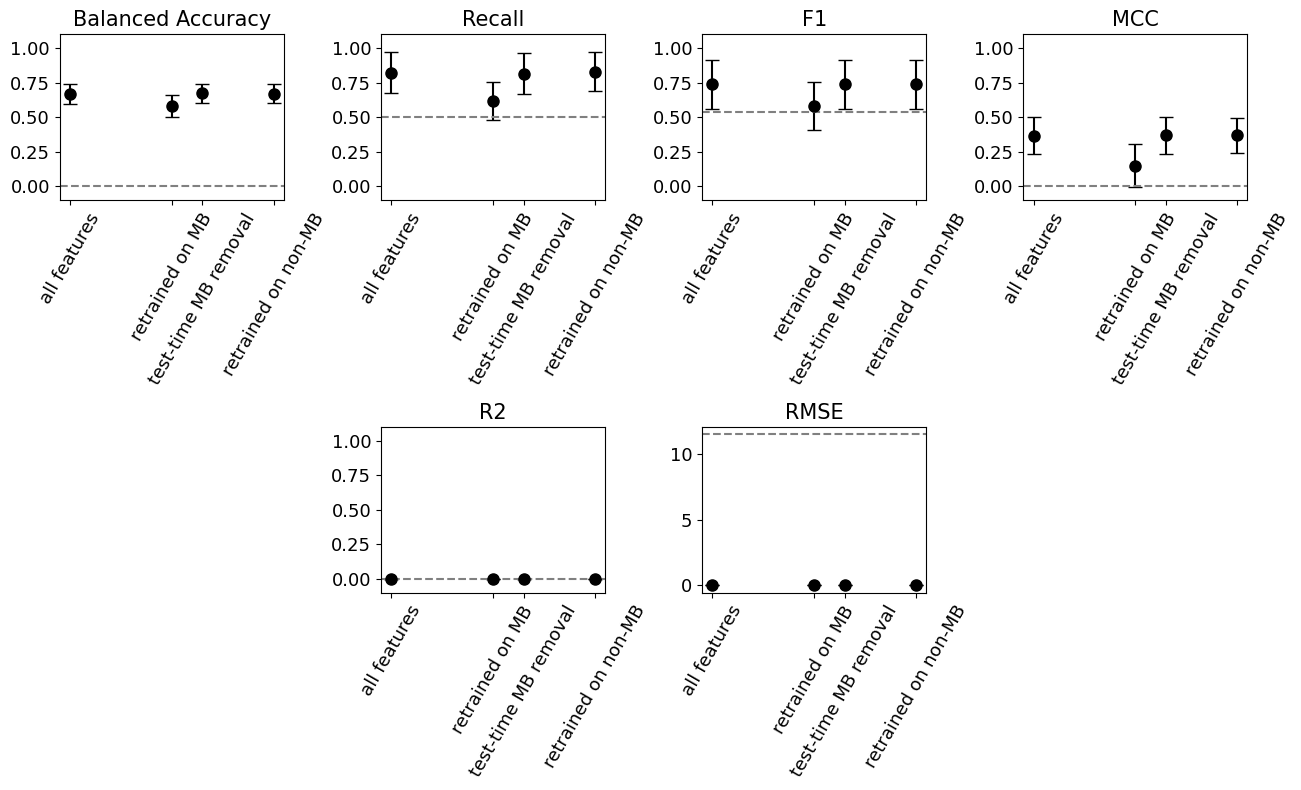

In [96]:
x = [0, 1, 1.3, 2]
xtick_labels = [
    "All features",
    "Retrained on MB",
    "Test-time MB removal",
    "Retrained on non-MB",
]

results = [
    metrics_full,
    metrics_mb_train_test,
    metrics_mb_zero_test,
    metrics_no_mb_train_test,
]

metrics = [
    ("balanced_accuracy", "Balanced Accuracy", (2, 4, 1), True),
    ("recall",            "Recall",            (2, 4, 2), True),
    ("f1",                "F1",                (2, 4, 3), True),
    ("mcc",               "MCC",               (2, 4, 4), True),
    ("r2",                "R²",                (2, 4, 6), True),
    ("rmse",              "RMSE",              (2, 4, 7), False),
]

plt.figure(figsize=(13, 8))

for metric, title, subplot, fix_ylim in metrics:
    plt.subplot(*subplot)

    for xpos, res in zip(x, results):
        plt.errorbar(
            xpos,
            res["test mean"][metric],
            yerr=res["test std"][metric],
            fmt="o",
            color="black",
            markersize=8,
            capsize=5,
        )

    plt.axhline(
        metrics_baseline["test baseline mean"][metric],
        color="grey",
        linestyle="--",
    )

    plt.xticks(x, xtick_labels, rotation=60, fontsize=13)
    plt.yticks(fontsize=13)
    plt.title(title, fontsize=15)

    if fix_ylim:
        plt.ylim(-0.1, 1.1)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/performance_on_mb_{TAX_LEVEL}_taxlevel.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

### 5.3 SHAP values

In [ ]:
# Create SHAP output directories if they do not exist
if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal")

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add")    

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat")     

In [36]:
# import numpy as np
# import xgboost as xgb
# from xgboost import XGBClassifier, XGBRegressor

# def shap_features(X_train, y_train, X_column_names, device, contin_flag=False):
#     # Initialize model
#     if not contin_flag:
#         model = XGBClassifier(
#             n_jobs=None if device != "cpu" else -1,
#             tree_method="gpu_hist" if device != "cpu" else "hist",
#             eval_metric="logloss",
#             use_label_encoder=False
#         )
#     else:
#         model = XGBRegressor(
#             n_estimators=100,
#             max_depth=5,
#             learning_rate=0.05,
#             n_jobs=-1,
#             tree_method="gpu_hist" if device != "cpu" else "hist",
#         )

#     # Convert torch tensors to numpy if needed
#     if hasattr(X_train, "cpu"):
#         X_np = X_train.cpu().numpy()
#         y_np = y_train.cpu().numpy()
#     else:
#         X_np, y_np = X_train, y_train

#     # Fit model
#     model.fit(X_np, y_np)

#     # ---- NEW PART: Use XGBoost’s built-in SHAP calculator ----
#     dtrain = xgb.DMatrix(X_np, label=y_np)
#     shap_values = model.get_booster().predict(dtrain, pred_contribs=True)

#     # The last column is the bias term (expected value)
#     shap_values = np.array(shap_values)
#     feature_shap_values = shap_values[:, :-1]  # remove bias term

#     # Compute mean absolute SHAP values
#     abs_shap_vals = np.abs(feature_shap_values)
#     mean_abs_shap_vals = np.mean(abs_shap_vals, axis=0)

#     # Sort by importance
#     sorted_indices = np.argsort(mean_abs_shap_vals)[::-1]
#     sorted_importances = mean_abs_shap_vals[sorted_indices]
#     sorted_names = [X_column_names[i] for i in sorted_indices]

#     return sorted_indices, sorted_importances, sorted_names, feature_shap_values


In [99]:
from feature_selection.feature_selection_utils import shap_features_contin

filename = f"{OUTPUT_DIRECTORY}/shap_list.json"
all_shap_lists_dict = defaultdict(int)
device = 'cpu'

# If the SHAP file exist - read it
if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_shap_lists_dict = json.load(f)
# Otherwise, find and save SHAP lists for each data split
else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
        X_column_names =  all_splits_dict[split_id]["feature_names"]

        X_np = X_val_train.cpu().numpy()  
        X_np = (X_np > 0).astype(int)

        sorted_cog_idx_by_shap, sorted_shap, sorted_names, shap_vals  = shap_features(X_np, y_label_train.cpu(), X_column_names, device, contin_flag = True) 

        all_shap_lists_dict[split_id] = sorted_names[:]#N]

    with open(filename, "w") as f:
        json.dump(dict(all_shap_lists_dict), f, indent=2)

Reading the existing file...


In [101]:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# import requests

# from sklearn.model_selection import GroupKFold

# import shap
# from xgboost import XGBClassifier, XGBRegressor
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import MaxAbsScaler
# from sklearn.model_selection import cross_val_score
# from sklearn.model_selection import cross_validate
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score
# from sklearn.metrics import matthews_corrcoef, make_scorer

# from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.feature_selection import SelectFromModel

# from sklearn.svm import LinearSVC
# from sklearn.feature_selection import SelectFromModel
# from sklearn.model_selection import StratifiedGroupKFold

# from sklearn.metrics import mutual_info_score
# from sklearn.feature_selection import mutual_info_regression
# from tqdm import tqdm
# from joblib import Parallel, delayed
# import joblib

# from sklearn.metrics import mean_squared_error,r2_score
# from sklearn.preprocessing import LabelEncoder
# label_encoder = LabelEncoder()
# from sklearn.utils.class_weight import compute_class_weight


In [102]:
# def xgboost_train_accur(
#         X_train, y_train, X_test, y_test,
#         device, model_path, groups=None,
#         n_splits=5, cv_val=None):

#     """
#     Trains XGBoost for the specified X/y train and test data.
#     Returns dictionaries with accuracy metrics for test set.
#     """

#     tree_method = "hist"

#     # ----- FIX: Normalize device for XGBoost -----
#     if isinstance(device, torch.device):
#         device_xgb = device.type      # "cuda" or "cpu"
#     elif isinstance(device, str):
#         device_xgb = device           # "cuda" or "cpu"
#     else:
#         raise ValueError(f"Unsupported device type: {device}")
#     # ---------------------------------------------

#     # Move tensors to CPU and convert
#     X_train_np = X_train.cpu().numpy()
#     y_train_np = y_train.cpu().numpy().flatten()
#     X_test_np  = X_test.cpu().numpy()
#     y_test_np  = y_test.cpu().numpy().flatten()

#     # ----- Build gating labels -----
#     range_labels = label_ogt_range(y_train_np)
#     label_to_int = {"low": 0, "high": 1}
#     range_ids = np.vectorize(label_to_int.get)(range_labels)

#     # Compute class weights for gating classifier
#     classes = np.unique(range_ids)
#     weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
#     class_weights = dict(zip(classes, weights))
#     sample_weights = np.array([class_weights[c] for c in range_ids])

#     range_ids_np = range_ids
#     sample_weights_np = sample_weights
#     # --------------------------------

#     # ----- Train gating classifier -----
#     gating_model_full = XGBClassifier(
#         n_jobs=-1,
#         tree_method=tree_method,
#         device=device_xgb,
#         objective="binary:logistic",
#         eval_metric="logloss"
#     )

#     gating_model_full.fit(
#         X_train_np, range_ids_np,
#         sample_weight=sample_weights_np
#     )

#     gate_probs_test = gating_model_full.predict_proba(X_test_np)
#     gate_preds_test = np.argmax(gate_probs_test, axis=1)

#     temp_bound = 50

#     # Binary true gate
#     gate_true_test = (y_test_np >= temp_bound).astype(int)
#     # -----------------------------------

#     # ----- Train expert regressors -----
#     low_mask  = y_train_np < temp_bound
#     high_mask = y_train_np >= temp_bound

#     model_low = XGBRegressor(
#         n_estimators=100, max_depth=5, learning_rate=0.05,
#         tree_method=tree_method, device=device_xgb
#     )

#     model_high = XGBRegressor(
#         n_estimators=100, max_depth=5, learning_rate=0.05,
#         tree_method=tree_method, device=device_xgb
#     )

#     model_low.fit(X_train_np[low_mask], y_train_np[low_mask])
#     model_high.fit(X_train_np[high_mask], y_train_np[high_mask])
#     # ------------------------------------

#     # Predictions
#     pred_low = model_low.predict(X_test_np)
#     pred_high = model_high.predict(X_test_np)

#     final_test_pred = (
#         gate_probs_test[:, 0] * pred_low +
#         gate_probs_test[:, 1] * pred_high
#     )

#     # ----- Collect test metrics -----
#     test_metrics = {
#         "accuracy": accuracy_score(gate_true_test, gate_preds_test),
#         "balanced_accuracy": balanced_accuracy_score(gate_true_test, gate_preds_test),
#         "precision": precision_score(gate_true_test, gate_preds_test),
#         "recall": recall_score(gate_true_test, gate_preds_test),
#         "f1": f1_score(gate_true_test, gate_preds_test),
#         "mcc": matthews_corrcoef(gate_true_test, gate_preds_test),
#         "rmse": np.sqrt(mean_squared_error(y_test_np, final_test_pred)),
#         "r2": r2_score(y_test_np, final_test_pred)
#     }

#     return None, test_metrics


In [103]:
# def xgboost_accur_select_features(X_train, X_test, y_train, y_test, sorted_indices, feat_step, device, split_id, add_rem_noise_rates, feat_removal = False, train_test_feat_apply = True, groups=None):
#     cv_accur_arr = []
#     test_accur_arr = []

#     cutoff = 50
    
#     indices = (
#         list(range(1, min(cutoff, len(sorted_indices))))
#         + list(range(cutoff, len(sorted_indices), feat_step))
#     )
    
#     num_feat = range(1,len(sorted_indices),feat_step)
#     num_feat_plot = []
#     print(len(indices))
#     for N in indices:
        
#         if feat_removal == False:
#             select_feat = list(sorted_indices[:N])
#             add_rem_name = "add"
#             model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add"
#         else:
#             select_feat = list(sorted_indices[N:])
#             add_rem_name = "rem"
#             model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal"
#         num_feat_plot.append(N) 
#         if train_test_feat_apply == True:
#             X_train_select_feat = X_train[:, select_feat] 
#             X_test_select_feat = X_test[:, select_feat]
#             model_filename = f"model_{add_rem_name}_shap_feat_N_{N}_split_id_{split_id}.pkl"
#             model_path = f"{model_dir}/{model_filename}"


#             if add_rem_noise_rates is not None:
#                 hard_fn_flag = True
#                 add_rate, rem_rate = add_rem_noise_rates

#                 select_feat_tensor = torch.tensor(select_feat, dtype=torch.long)
#                 X_test_select_feat = flip_with_fractional_noise(
#                     X_test_select_feat,
#                     add_rate,
#                     rem_rate,
#                     noise_std=0.3,
#                     hard_fn_flag=hard_fn_flag
#                 )
                
#         else:
#             X_train_select_feat = X_train.clone()  
#             X_test_select_feat = X_test.clone()
#             # Put the features that are not in select_feat to 0
#             all_features = torch.arange(X_test.shape[1])
#             unselected_feat = all_features[~torch.isin(all_features, torch.tensor(select_feat))]
#             X_test_select_feat[:, unselected_feat] = 0
            
#             #X_test_select_feat[:, select_feat] = 0
#             model_filename = f"model_all_feat_split_id_{split_id}.pkl"
#             model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat"
#             model_path = f"{model_dir}/{model_filename}"

#             if add_rem_noise_rates is not None:
#                 hard_fn_flag = True
#                 add_rate, rem_rate = add_rem_noise_rates
                
#                # select_feat_tensor = torch.tensor(select_feat)
                
#                 select_feat_tensor = torch.tensor(select_feat, dtype=torch.long)

#                 X_test_select_feat[:, select_feat] = flip_with_fractional_noise(
#                     X_test_select_feat[:, select_feat],
#                     add_rate,
#                     rem_rate,
#                     noise_std=0.3,
#                     hard_fn_flag=hard_fn_flag
#                 )
        
#         cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_train_select_feat, y_train, X_test_select_feat, y_test, device, model_path, groups=groups)
#         cv_accur_arr.append(cv_accuracy_scores)
#         test_accur_arr.append(test_accuracy_scores)

#     return cv_accur_arr,  test_accur_arr, num_feat_plot 

In [104]:
# import os
# import pickle
# from collections import defaultdict
# from utils.utils_ancestral_predict import flip_with_fractional_noise
# #from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# def shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict, add_rem_noise_rates=None):
#     # Load if file exists
#     if os.path.exists(filename):  #False:#
#         with open(filename, "rb") as f:
#             accuracy_curves_all_splits_add_feat_train_test = pickle.load(f)
#         print(f"Loaded existing results from {filename}")
#     else:
#         accuracy_curves_all_splits_add_feat_train_test = defaultdict(dict)
#         print("No existing file found. Starting fresh...")
    
#         feat_step = feat_step
#         feat_removal = feat_removal
#         accuracy_curves_all_splits_add_feat_train_test = defaultdict(dict) 
#         for split_id in all_shap_lists_dict.keys():
    
#             X_val_train =  all_splits_dict[int(split_id)]["X_train"]
#             y_label_train =  all_splits_dict[int(split_id)]["y_train"]
#             X_val_test =  all_splits_dict[int(split_id)]["X_test"]
#             y_label_test =  all_splits_dict[int(split_id)]["y_test"]
#             X_column_names =  all_splits_dict[int(split_id)]["feature_names"]
#             taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]
            
#             shap_list = all_shap_lists_dict[split_id]
#             X_column_names = list(X_column_names)
#             indices = [X_column_names.index(f) for f in shap_list if f in X_column_names]

#             # if add_rem_noise_rates is not None: #TODO: fix this part 
#             #     hard_fn_flag = True
#             #     add_rate, rem_rate = add_rem_noise_rates
#             #     X_val_test_noisy = flip_with_fractional_noise(
#             #         X_val_test, add_rate, rem_rate, noise_std=0.3, hard_fn_flag=hard_fn_flag
#             #     )
#             #     cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test_noisy.cpu(), y_label_train.cpu(), y_label_test.cpu(), indices, feat_step, DEVICE, split_id, feat_removal,  train_test_feat_apply_flag, groups = taxa_group_names_train)    
#             # else:
#           #  print(f"add_rem_noise_rates = {add_rem_noise_rates}")
#             cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), indices, feat_step, DEVICE, split_id, add_rem_noise_rates, feat_removal,  train_test_feat_apply_flag, groups = taxa_group_names_train)    
            
#             accuracy_curves_all_splits_add_feat_train_test[split_id]['cv_accur'] = cv_accur_arr
#             accuracy_curves_all_splits_add_feat_train_test[split_id]['test_accur'] = test_accur_arr
#             accuracy_curves_all_splits_add_feat_train_test[split_id]['num_feat'] = num_feat
#             print(f"Split {split_id} done")
        
#         with open(filename, "wb") as f:
#             pickle.dump(accuracy_curves_all_splits_add_feat_train_test, f)
#     return accuracy_curves_all_splits_add_feat_train_test     

In [105]:
from feature_selection.feature_selection_utils import shap_curves_file

# Find accuracies for the feature list where the features are gradually added wrt their SHAP values (starting from the most important ones): re-trained without the features

feat_step = 10                    # removel step size
feat_removal = False              # flag for weather are gradually added (False), or removed (True)
train_test_feat_apply_flag = True # weather the feature removal strategy is applied to the train+test (True) only or test only data (False)
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_train_test.pkl"
accuracy_curves_all_splits_add_feat_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

Loaded existing results from ../data_gc/outputs/phylum/accuracy_curves_all_splits_add_feat_train_test.pkl


In [106]:
feat_step = 10
feat_removal = False
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_test.pkl"

accuracy_curves_all_splits_add_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

Loaded existing results from ../data_gc/outputs/phylum/accuracy_curves_all_splits_add_feat_test.pkl


In [124]:
feat_step = 10
feat_removal = True
train_test_feat_apply_flag = True
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_train_feat_test.pkl"


accuracy_curves_all_splits_rem_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict) 

Loaded existing results from ../data_gc/outputs/phylum/accuracy_curves_all_splits_rem_train_feat_test.pkl


In [114]:
feat_step = 10
feat_removal = True
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_test.pkl"


accuracy_curves_all_splits_rem_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict) 

Loaded existing results from ../data_gc/outputs/phylum/accuracy_curves_all_splits_rem_feat_test.pkl


In [115]:
# def accur_curves(accuracy_curves_all_splits_add_feat):
#     bal_accur_curves = []
#     recall_curves = []
#     mcc_curves = []
#     f1_curves = []
#     num_feat = []
#     for key in accuracy_curves_all_splits_add_feat.keys():
#         mcc_curve = []
#         f1_curve = []
#         bal_accur_curve = []
#         recall_curve = []
#         for point in accuracy_curves_all_splits_add_feat[key]["test_accur"]:
#             bal_accur_curve.append(point['balanced_accuracy'])
#             recall_curve.append(point['recall'])
#             mcc_curve.append(point['mcc'])
#             f1_curve.append(point['f1'])
#         bal_accur_curves.append(bal_accur_curve) 
#         recall_curves.append(recall_curve)     
#         mcc_curves.append(mcc_curve) 
#         f1_curves.append(f1_curve) 
#         num_feat.append(accuracy_curves_all_splits_add_feat[key]["num_feat"])
#     return bal_accur_curves, recall_curves, mcc_curves, f1_curves, num_feat    

In [116]:
# def accur_curves_regr(accuracy_curves_all_splits_add_feat):
#     r2_curves = []
#     rmse_curves = []
#     num_feat = []
#     for key in accuracy_curves_all_splits_add_feat.keys():
#         r2_curve = []
#         rmse_curve = []
#         for point in accuracy_curves_all_splits_add_feat[key]["test_accur"]:
#             r2_curve.append(point['r2'])
#             rmse_curve.append(point['rmse'])
#         r2_curves.append(r2_curve) 
#         rmse_curves.append(rmse_curve) 
#         num_feat.append(accuracy_curves_all_splits_add_feat[key]["num_feat"])
#     return r2_curves, rmse_curves, num_feat    

In [117]:
# def find_mean_std_curve(mcc_curves):
#     min_len = min(len(c) for c in mcc_curves)
#     arr = np.array([c[:min_len] for c in mcc_curves])
#     mean_curve = np.mean(arr, axis=0)
#     std_curve = np.std(arr, axis=0)
#     return mean_curve, std_curve


In [118]:
# import numpy as np

# def find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95):
#     y = np.asarray(mean_curve_train_test)
#     target = 0.95 * y[-1]
#     idx_95 = np.where(y >= target)[0][0]
#     return x_train_test[idx_95]

In [120]:
# import numpy as np

# def find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95):
#     y = np.asarray(mean_curve_train_test)
#     threshold = thresh_percent * y[0]
    
#     idx_95 = np.where(y <= threshold)[0][0]
#     return x_train_test[idx_95]

Index for balanced accuracy = 15
Index for recall accuracy = 36
Index for mcc: Mean = 44.7, std = 75.74305248668026
Index for mcc accuracy = 110
Index for f1 accuracy = 26
Index for RMSE accuracy = 2
Index for R2 accuracy = 200


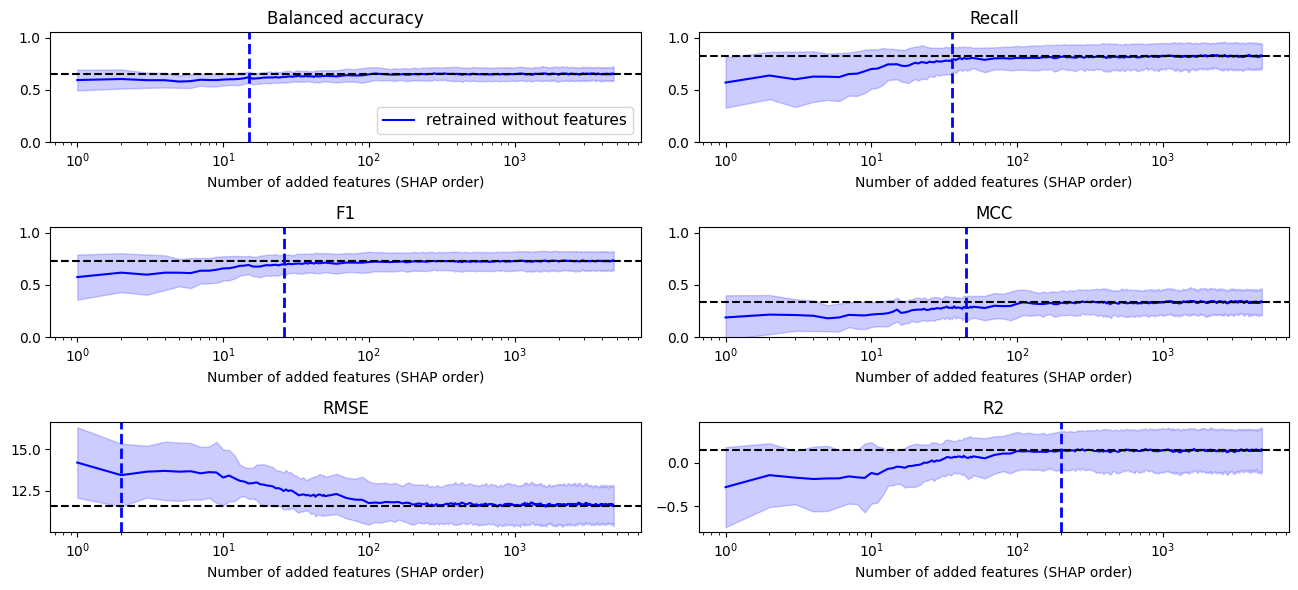

In [121]:
import numpy as np
import matplotlib.pyplot as plt

bal_accur_curve_train_test, recall_curves_train_test, mcc_curv_train_test, f1_curves_train_test, num_feat_train_test = accur_curves(accuracy_curves_all_splits_add_feat_train_test)
bal_accur_curve_test, recall_curves_test, mcc_curves_test, f1_curves_test, num_feat_test = accur_curves(accuracy_curves_all_splits_add_feat_test)


plt.figure(figsize=(13, 6))

plt.subplot(3, 2, 1)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(bal_accur_curve_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='retrained without features')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal


index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for balanced accuracy = {index}")

# x_test = num_feat_test[0]
# mean_curve_test, std_curve_test = find_mean_std_curve(bal_accur_curve_test)
# plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
# plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
# plt.axhline(y=mean_curve_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal
plt.legend(fontsize=11)
plt.xlabel('Number of added features (SHAP order)')
plt.title('Balanced accuracy')
plt.ylim([0,1.05])

plt.xscale("log")
# plt.legend()

plt.subplot(3, 2, 2)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(recall_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for recall accuracy = {index}")


# x_test = num_feat_test[0]
# mean_curve_test, std_curve_test = find_mean_std_curve(recall_curves_test)
# plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
# plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
# plt.axhline(y=mean_curve_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

plt.xlabel('Number of added features (SHAP order)')
plt.title('Recall')
plt.ylim([0,1.05])
plt.xscale("log")
#plt.legend()

plt.subplot(3, 2, 4)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(mcc_curv_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal



mcc_indices = []
for curve in mcc_curv_train_test:
    ind = find_increas_curve_index(curve, x_train_test, thresh_percent = 0.95)
    mcc_indices.append(ind)
print(f"Index for mcc: Mean = {np.mean(mcc_indices)}, std = {np.std(mcc_indices)}")

index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(np.mean(mcc_indices), color="blue", linestyle="--", linewidth=2)
print(f"Index for mcc accuracy = {index}")

plt.xlabel('Number of added features (SHAP order)')
plt.title('MCC')
plt.ylim([0,1.05])
plt.xscale("log")

plt.subplot(3, 2, 3)
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(f1_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue')#, label='Mean accuracy')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal


index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for f1 accuracy = {index}")

plt.xlabel('Number of added features (SHAP order)')
plt.title('F1')
plt.ylim([0,1.05])
plt.xscale("log")


r2_curves_train_test, rmse_curves_train_test, num_feat_train_test = accur_curves_regr(accuracy_curves_all_splits_add_feat_train_test)
r2_curves_test, rmse_curves_test, num_feat_test = accur_curves_regr(accuracy_curves_all_splits_add_feat_test)


plt.subplot(3, 2, 5)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(rmse_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for RMSE accuracy = {index}")

plt.xlabel('Number of added features (SHAP order)')
plt.title('RMSE')
#plt.ylim([0,1.05])
plt.xscale("log")

plt.subplot(3, 2, 6)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(r2_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for R2 accuracy = {index}")

plt.xlabel('Number of added features (SHAP order)')
plt.title('R2')
#plt.ylim([0,1.05])
plt.xscale("log")


plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/shap_order_feature_add_{TAX_LEVEL}_taxlevel.svg", format="svg", bbox_inches='tight') #<-------save as pdf

plt.show()


In [122]:
# import numpy as np

# def find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent=0.95, stability=2):
#     y = np.asarray(mean_curve_train_test)
#     threshold = thresh_percent * y[0]

#     for i in range(len(y) - stability + 1):
#         if y[i] <= threshold and np.all(y[i:i+stability] <= threshold):
#             return x_train_test[i]

#     return None

Index for balanced accuracy = 4480
Index for balanced accuracy = 4480
Index for recall = 2370
Index for f1 = 4410
!!Mean train-test = 729.0, std = 711.0
Index for mcc = 460
!!Mean test only = 79.5, std = 70.5
Index for mcc test only = 37
Index for RMSE accuracy = 4620
Index for R2 accuracy = 13
Index for R2 test only = 28


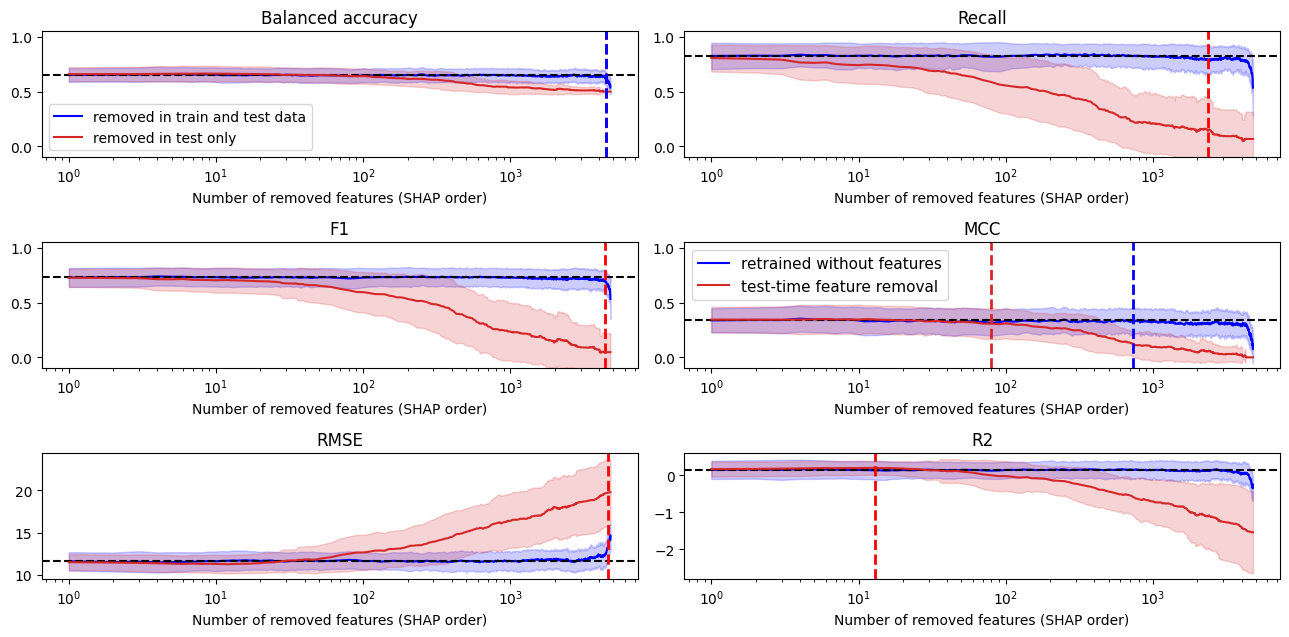

In [125]:
import numpy as np
import matplotlib.pyplot as plt
bal_accur_curve_train_test, recall_curves_train_test, mcc_curves_train_test, f1_curves_train_test, num_feat_train_test = accur_curves(accuracy_curves_all_splits_rem_train_test)
bal_accur_curve_test, recall_curves_test, mcc_curves_test, f1_curves_test, num_feat_test = accur_curves(accuracy_curves_all_splits_rem_feat_test)


plt.figure(figsize=(13, 6))
plt.subplot(3, 2, 1)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(bal_accur_curve_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='removed in train and test data')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(bal_accur_curve_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='removed in test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for balanced accuracy = {index}")

index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="blue", linestyle="--", linewidth=2)
print(f"Index for balanced accuracy = {index}")


plt.xlabel('Number of removed features (SHAP order)')
plt.title('Balanced accuracy')
plt.ylim([-0.1,1.05])
plt.xscale("log")
plt.legend()

plt.subplot(3, 2, 2)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(recall_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(recall_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for recall = {index}")

plt.xlabel('Number of removed features (SHAP order)')
plt.title('Recall')
plt.ylim([-0.1,1.05])
plt.xscale("log")
#plt.legend()

plt.subplot(3, 2, 3)
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(f1_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue')#, label='Mean accuracy')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for f1 = {index}")

mean_curve_test, std_curve_test = find_mean_std_curve(f1_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red')#, label='Mean accuracy')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizonta



plt.xlabel('Number of removed features (SHAP order)')
plt.title('F1')
plt.ylim([-0.1,1.05])
plt.tight_layout()
plt.xscale("log")


plt.subplot(3, 2, 4)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(mcc_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='retrained without features')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(mcc_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test-time feature removal')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

mcc_indices = []
for curve in mcc_curves_train_test:
    if curve[0] > 0.5:
        ind = find_decreas_curve_index(curve, x_train_test, thresh_percent = 0.95, stability=5)
        mcc_indices.append(ind)
mcc_mean_rem_tr_test =  np.mean(mcc_indices)   
mcc_stdn_rem_tr_test  = np.std(mcc_indices)
print(f"!!Mean train-test = {mcc_mean_rem_tr_test}, std = {mcc_stdn_rem_tr_test}")
plt.axvline(mcc_mean_rem_tr_test, color="blue", linestyle="--", linewidth=2)


index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
#plt.axvline(mcc_mean_rem_tr_test, color="tab:red", linestyle="--", linewidth=2)
print(f"Index for mcc = {index}")

mcc_indices = []
for curve in mcc_curves_test:
    if curve[0] > 0.5:
        ind = find_decreas_curve_index(curve, x_test, thresh_percent = 0.95, stability=1)
        mcc_indices.append(ind)
mcc_mean_rem_tr_test =  np.mean(mcc_indices)   
mcc_stdn_rem_tr_test  = np.std(mcc_indices)
print(f"!!Mean test only = {mcc_mean_rem_tr_test}, std = {mcc_stdn_rem_tr_test}")
plt.axvline(mcc_mean_rem_tr_test, color="tab:red", linestyle="--", linewidth=2)



index = find_decreas_curve_index(mean_curve_test, x_test, thresh_percent = 0.95)
# plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for mcc test only = {index}")

plt.xlabel('Number of removed features (SHAP order)')
plt.title('MCC')
plt.legend(fontsize=11)
plt.ylim([-0.1,1.05])
plt.xscale("log")
#plt.axvline(index, color="red", linestyle="--", linewidth=2)
#plt.legend()


r2_curves_train_test, rmse_curves_train_test, num_feat_train_test = accur_curves_regr(accuracy_curves_all_splits_rem_train_test)
r2_curves_test, rmse_curves_test, num_feat_test = accur_curves_regr(accuracy_curves_all_splits_rem_feat_test)


plt.subplot(3, 2, 5)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(rmse_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal


x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(rmse_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal


index = find_increas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for RMSE accuracy = {index}")

plt.xlabel('Number of removed features (SHAP order)')
plt.title('RMSE')
#plt.ylim([0,1.05])
plt.xscale("log")




plt.subplot(3, 2, 6)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(r2_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal


x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(r2_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
#plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal



index = find_decreas_curve_index(mean_curve_train_test, x_train_test, thresh_percent = 0.95)
plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for R2 accuracy = {index}")


index = find_decreas_curve_index(mean_curve_test, x_test, thresh_percent = 0.95)
# plt.axvline(index, color="red", linestyle="--", linewidth=2)
print(f"Index for R2 test only = {index}")

plt.xlabel('Number of removed features (SHAP order)')
plt.title('R2')
#plt.ylim([0,1.05])
plt.xscale("log")



plt.savefig(f"{OUTPUT_DIRECTORY}/plots/shap_order_feature_removal_{TAX_LEVEL}_taxlevel.svg", format="svg", bbox_inches='tight') #<-------save as pdf
plt.show()
